In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("crime.csv")
df.head()

,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [3]:
df.info()
df.shape
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 8 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Sl. No.                                          39 non-null     object 
 1   State/UT                                         39 non-null     object 
 2   2020                                             39 non-null     int64  
 3   2021                                             39 non-null     int64  
 4   2022                                             39 non-null     int64  
 5   Mid-Year Projected Population (in Lakhs) (2022)  39 non-null     float64
 6   Rate of Cognizable Crimes (IPC) (2022)           39 non-null     float64
 7   Chargesheeting Rate (2022)                       39 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.6+ KB


np.int64(0)

In [4]:
df = df.drop(columns="Sl. No.")
df.head()

,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,Assam,111558,119883,59315,354.9,167.1,32.6
3,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [5]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "State/UT": "State",
    "2020": "Crime_2020",
    "2021": "Crime_2021",
    "2022": "Crime_2022"
})

df.head()

,State,Crime_2020,Crime_2021,Crime_2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,Assam,111558,119883,59315,354.9,167.1,32.6
3,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [6]:
df = df[~df["State"].isin([
    "Total State (S)", 
    "Total UT(S)", 
    "Total All India"   # ✅ FIXED
])]

df.reset_index(drop=True, inplace=True)
df.shape

(36, 7)

In [7]:
df = df.rename(columns={
    "Mid-Year Projected Population (in Lakhs) (2022)": "Population_2022",
    "Rate of Cognizable Crimes (IPC) (2022)": "Crime_rate_2022",
    "Chargesheeting Rate (2022)": "Chargesheeting_Rate"   # ✅ FIXED
})

df.columns

Index(['State', 'Crime_2020', 'Crime_2021', 'Crime_2022', 'Population_2022',
       'Crime_rate_2022', 'Chargesheeting_Rate'],
      dtype='object')

In [8]:
df.describe()

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesheeting_Rate
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,118176.555556,101760.000000,98927.194444,383.261111,241.252778,67.991667
std,176923.509449,118652.699382,117142.926576,497.400312,235.523156,20.334367
min,107.000000,89.000000,64.000000,0.700000,45.400000,10.400000
25%,2524.500000,2479.750000,2934.250000,16.075000,138.300000,57.375000
50%,50451.500000,47069.000000,46232.000000,255.250000,175.300000,75.350000
75%,165794.250000,163026.250000,157014.000000,566.250000,292.075000,82.425000
max,891700.000000,367218.000000,401787.000000,2340.900000,1424.100000,96.000000


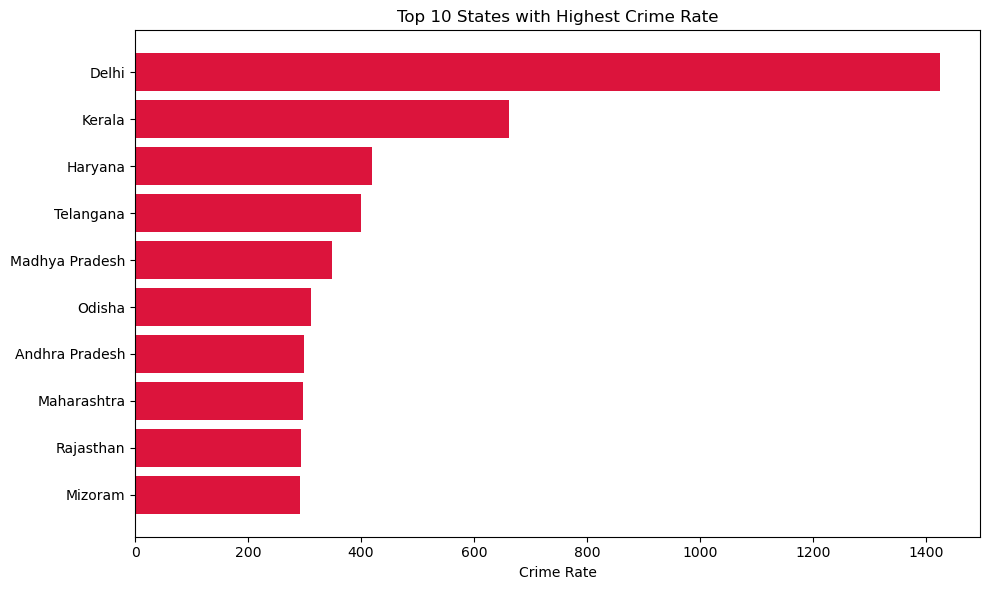

In [9]:
top10 = df.nlargest(10, "Crime_rate_2022")[["State", "Crime_rate_2022"]]

plt.figure(figsize=(10,6))
plt.barh(top10['State'], top10["Crime_rate_2022"], color="crimson")
plt.xlabel("Crime Rate")
plt.title("Top 10 States with Highest Crime Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Crime_2020    4254356
Crime_2021    3663360
Crime_2022    3561379
dtype: int64


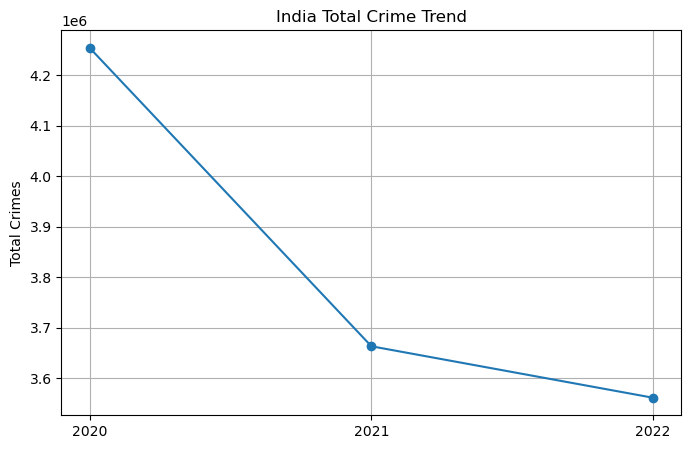

In [10]:
years = ['Crime_2020', 'Crime_2021', 'Crime_2022']
total = df[years].sum()

print(total)

plt.figure(figsize=(8,5))
plt.plot(['2020','2021','2022'], total.values, marker="o")
plt.title("India Total Crime Trend")
plt.ylabel("Total Crimes")
plt.grid(True)
plt.show()

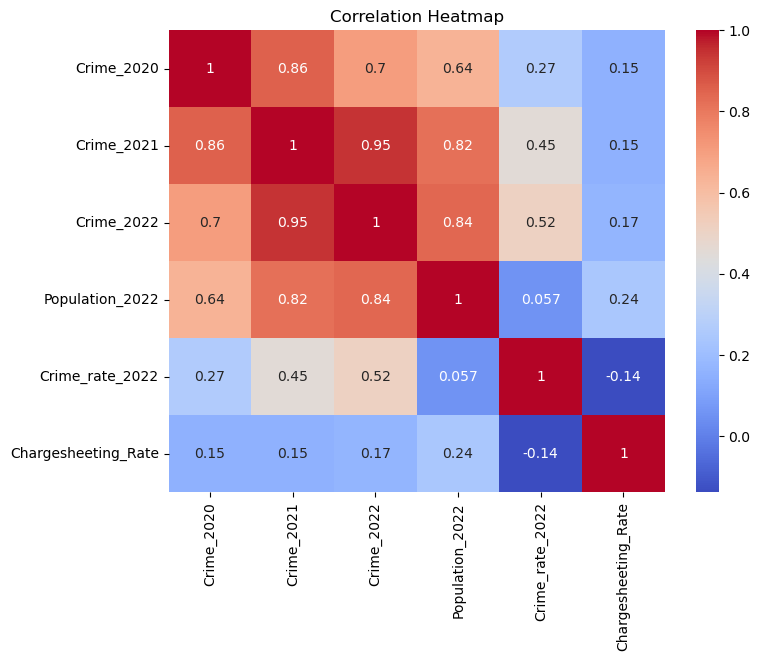

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns="State").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Crime change
df['Crime_change_20_21'] = df["Crime_2021"] - df["Crime_2020"]
df['Crime_change_21_22'] = df["Crime_2022"] - df["Crime_2021"]

# Percentage change
df['Crime_change_pct'] = ((df["Crime_2022"] - df["Crime_2020"]) / df["Crime_2020"]) * 100

df.head()

,State,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesheeting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050
2,Assam,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348
3,Bihar,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148


In [13]:
# ✅ KEEP THIS FEATURE (DON'T DELETE)
df['Crime_per_lakh_2022'] = df['Crime_2022'] / df['Population_2022']

# Average crime
df['Crime_Average'] = (df['Crime_2020'] + df['Crime_2021'] + df['Crime_2022']) / 3

df.head()

,State,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesheeting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_per_lakh_2022,Crime_Average
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,298.976051,175718.333333
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,148.903226,2392.666667
2,Assam,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348,167.131586,96918.666667
3,Bihar,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543,168.150243,197261.000000
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148,246.484140,69852.333333


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                36 non-null     object 
 1   Crime_2020           36 non-null     int64  
 2   Crime_2021           36 non-null     int64  
 3   Crime_2022           36 non-null     int64  
 4   Population_2022      36 non-null     float64
 5   Crime_rate_2022      36 non-null     float64
 6   Chargesheeting_Rate  36 non-null     float64
 7   Crime_change_20_21   36 non-null     int64  
 8   Crime_change_21_22   36 non-null     int64  
 9   Crime_change_pct     36 non-null     float64
 10  Crime_per_lakh_2022  36 non-null     float64
 11  Crime_Average        36 non-null     float64
dtypes: float64(6), int64(5), object(1)
memory usage: 3.5+ KB


In [22]:
# One Hot Encoding for State column
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

df_encoded.head()

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesheeting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_per_lakh_2022,...,State_Puducherry,State_Punjab,State_Rajasthan,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal
0,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,298.976051,...,False,False,False,False,False,False,False,False,False,False
1,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,148.903226,...,False,False,False,False,False,False,False,False,False,False
2,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348,167.131586,...,False,False,False,False,False,False,False,False,False,False
3,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543,168.150243,...,False,False,False,False,False,False,False,False,False,False
4,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148,246.484140,...,False,False,False,False,False,False,False,False,False,False


In [29]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesheeting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_per_lakh_2022,...,State_Puducherry,State_Punjab,State_Rajasthan,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal
0,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,298.976051,...,0,0,0,0,0,0,0,0,0,0
1,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,148.903226,...,0,0,0,0,0,0,0,0,0,0
2,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348,167.131586,...,0,0,0,0,0,0,0,0,0,0
3,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543,168.150243,...,0,0,0,0,0,0,0,0,0,0
4,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148,246.484140,...,0,0,0,0,0,0,0,0,0,0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target
X = df_encoded.drop(columns=['Crime_2022'])
y = df_encoded['Crime_2022']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 1.0


In [25]:
from sklearn.model_selection import cross_val_score

In [26]:
# Model already bana hua hai (LinearRegression)

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("CV Scores:", scores)

CV Scores: [1. 1. 1. 1. 1.]


In [27]:
print("Mean CV Score:", scores.mean())

Mean CV Score: 1.0
